# 라이브러리 선언하기

In [1]:
import pandas as pd
import sklearn

In [2]:
dataUrl="https://raw.githubusercontent.com/hyokwan/python-lecture/refs/heads/master/dataset/feature_regression_example.csv"

# 데이터 전처리

In [3]:
featuresData = pd.read_csv(dataUrl)
featuresData.head(2)


,REGIONID,PRODUCTGROUP,PRODUCT,ITEM,YEARWEEK,YEAR,WEEK,QTY,HOLIDAY,HCLUS,PROMOTION,PRO_PERCENT
0,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201501,2015,1,1225,Y,1,Y,0.209442
1,SEOUL_BANK_001,PG02,PRODUCT0010,ITEM0115,201502,2015,2,968,N,4,Y,0.209442


In [4]:
featuresData.shape

(105, 12)

In [5]:
from sklearn.preprocessing import LabelEncoder
# 라벨인코드 인스턴스 생성
ynLabel = LabelEncoder()
featuresData["LE_PROMOTION"] = ynLabel.fit_transform(featuresData.PROMOTION)
featuresData["LE_HOLIDAY"] = ynLabel.fit_transform(featuresData.HOLIDAY)

# ynLabel.inverse_transform(featuresData.LE_PROMOTION)
featuresData.head(2)

featuresData.loc[(featuresData.LE_PROMOTION == "Y") & (featuresData.PROMOTION == 0)]

,REGIONID,PRODUCTGROUP,PRODUCT,ITEM,YEARWEEK,YEAR,WEEK,QTY,HOLIDAY,HCLUS,PROMOTION,PRO_PERCENT,LE_PROMOTION,LE_HOLIDAY


In [6]:
featuresData.shape

(105, 14)

In [7]:
testLabel = LabelEncoder()

In [8]:
testList = ['a','b','c','d','e','f']
testDf = pd.DataFrame(testList, columns=["testCol"])
testDf


,testCol
0,a
1,b
2,c
3,d
4,e
5,f


In [9]:
testLabel.fit_transform(testList)

array([0, 1, 2, 3, 4, 5])

In [10]:
testDf["LE_testCol"] = testLabel.fit_transform(testList)
testDf

,testCol,LE_testCol
0,a,0
1,b,1
2,c,2
3,d,3
4,e,4
5,f,5


### A-2. 특성선정 및 데이터 분리

In [11]:
# label = 정답지 = 내가 알고 싶은 값
label = ["QTY"]
# features = ?
# 정답지에 영향을 끼치는 요인을 찾는 방법 -> 상관 분석
corrDf = featuresData.corr(numeric_only=True)
features = list(corrDf.loc[(abs(corrDf.QTY) > 0.5) & (corrDf.QTY !=1)].index)
print(f"특정선정 완료! 정답지 = {label} 문제지 = {features}")

특정선정 완료! 정답지 = ['QTY'] 문제지 = ['HCLUS', 'PRO_PERCENT', 'LE_PROMOTION', 'LE_HOLIDAY']


In [12]:
from sklearn.model_selection import train_test_split

In [13]:
# 데이터 분리( 문제지, 정답지 같이 분리해야한다 )
spltRatio = 0.2
trainData, testData = train_test_split(featuresData, test_size=spltRatio, random_state=5)
trainDataLabel = trainData.loc[:, label]
trainDataFeatures = trainData.loc[:, features]
testDataLabel = testData.loc[:, label]
testDataFeatures = testData.loc[:, features]
print(f"훈련데이터 정답지 shape: {trainDataLabel.shape}")
print(f"훈련데이터 문제지 shape: {trainDataFeatures.shape}")
print(f"테스트데이터 정답지 shape: {testDataLabel.shape}")
print(f"테스트데이터 문제지 shape: {testDataFeatures.shape}")

훈련데이터 정답지 shape: (84, 1)
훈련데이터 문제지 shape: (84, 4)
테스트데이터 정답지 shape: (21, 1)
테스트데이터 문제지 shape: (21, 4)


# B. 모델 적용

B-1. 모델 적용

In [ ]:
from sklearn.tree import DecisionTreeRegressor

In [ ]:
# 모델 선언
dtModel = DecisionTreeRegressor(random_state=5)
# 모델 훈련
fittedModel = dtModel.fit(trainDataFeatures, trainDataLabel)

DecisionTreeRegressor(random_state=5)

In [29]:
features[1]

'PRO_PERCENT'

In [34]:
trainData["LABEL2"] = trainData.QTY.mean()

In [38]:
trainData["DIFF"] = trainData["QTY"] - trainData["LABEL2"]
trainData["DIFF_SQUARE"] = trainData["DIFF"]**2
trainData.DIFF_SQUARE.mean()

np.float64(693549.0038265307)

In [39]:
trainData.QTY.mean()

np.float64(1248.8214285714287)

In [32]:
trainData.loc[trainData.PRO_PERCENT <= 0.224].shape

(41, 14)

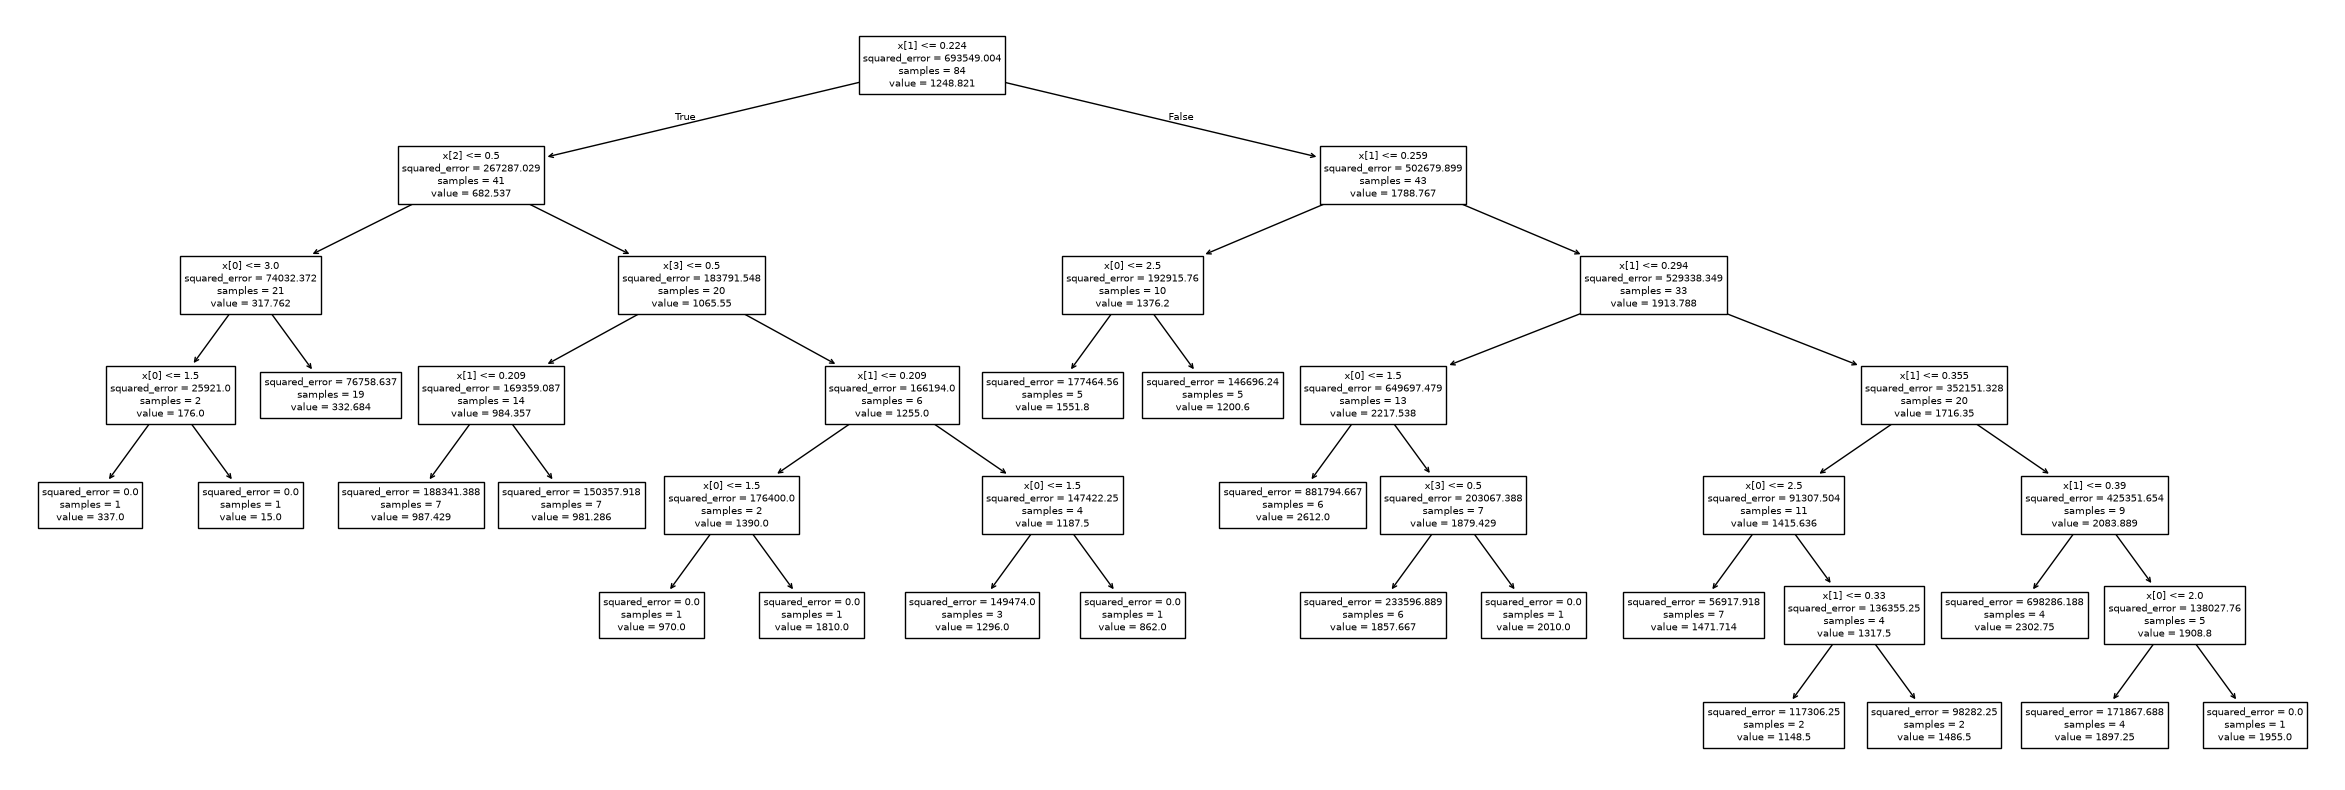

In [28]:
# 머신러인 트리형 모델 중 트리를 시각화하는 라이브러리
from sklearn.tree import plot_tree
# 파이썬 기본 차트 생성 라이브러리
import matplotlib.pyplot as plt

# figure 도화지를 생성하는 가로 20, 세로 7
plt.figure(figsize=(30,10))
plot_tree(fittedModel)
plt.savefig("dtModel.png", dpi = 300)